 # Forced Duffing Oscillator (Chaotic)

In [48]:
# import all the necessary libraries
import pysindy as ps
import numpy as np

from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error

In [78]:
# The Duffing oscillator system
def duffing(t, x, delta=0.2, alpha=1, beta=-1, gamma=0.3, omega=1):
    return [x[1], 
           -beta * x[0] - delta * x[1] - alpha * x[0] ** 3 + gamma * np.cos(x[2]),
           omega]

In [79]:
# generate the data for testing
start = 0
end = 100
step = 0.01
t_span = [start, end]
x0 = [0.3, 0.1, 0]
sol = solve_ivp(duffing, t_span, x0, dense_output=True)
t = np.arange(start, end+step/10, step)
x = sol.sol(t).T

In [84]:
# The feature names of the columns of y
feature_names = ['x1', 'x2', 'omega t']

# Which feature library to use
# Here I'm using a polynomial library that contains all combinations of the columns upto the degree 3
poly_lib = ps.PolynomialLibrary(degree=3)
fourier_lib = ps.FourierLibrary()

inputs_temp = np.tile([0, 1, 2], 2)
inputs_per_library = np.reshape(inputs_temp, (2,3))

inputs_per_library[0,2] = 1
inputs_per_library[1,0] = 2
inputs_per_library[1,1] = 2
inputs_per_library[1,2] = 2
print(inputs_per_library)

generalized_library = ps.GeneralizedLibrary(
    [poly_lib, fourier_lib],
inputs_per_library = inputs_per_library)

# Differentiation method
differentiation_method = ps.SmoothedFiniteDifference(order=2)

# Optimizer
opt = ps.SR3(threshold=0.1,thresholder='L0',max_iter=30)
# opt = ps.STLSQ(threshold=0.1)
# opt = ps.STLSQ(threshold=0.2)

# Building the model
model=ps.SINDy(differentiation_method=differentiation_method,
               feature_library = generalized_library,
               feature_names=feature_names, 
              optimizer=opt)

# Fitting the model to the training data
model.fit(x,t=t)

# Print the model
model.print()
model.get_feature_names()

[[0 1 1]
 [2 2 2]]
(x1)' = 1.000 x2
(x2)' = 0.997 x1 + -0.198 x2 + -0.995 x1^3 + 0.299 cos(1 omega t)
(omega t)' = 1.000 1


['1',
 'x1',
 'x2',
 'x1^2',
 'x1 x2',
 'x2^2',
 'x1^3',
 'x1^2 x2',
 'x1 x2^2',
 'x2^3',
 'sin(1 omega t)',
 'cos(1 omega t)']

In [85]:
# Simulate the identified system 
sim = model.simulate(x0,t=t) 

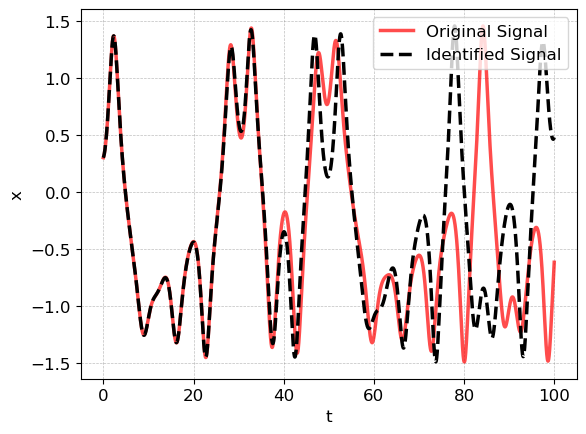

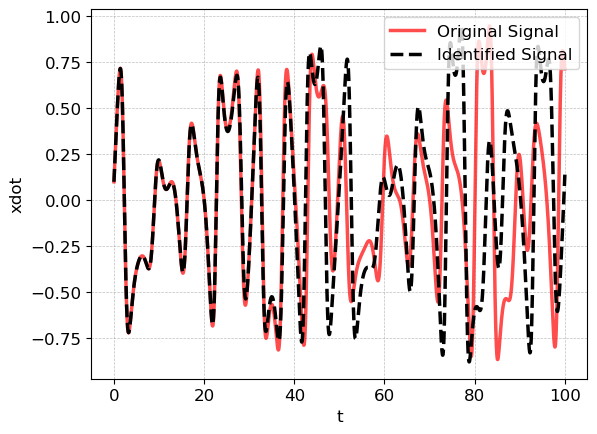

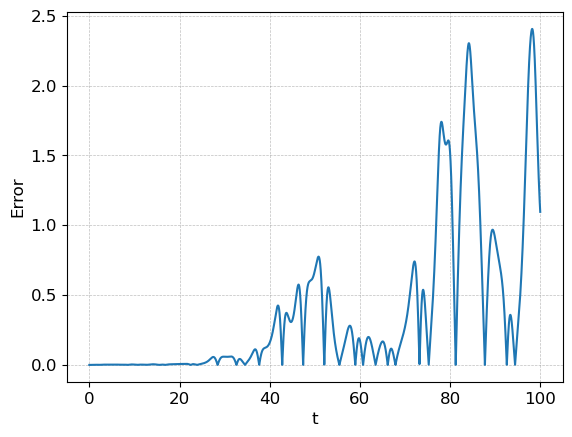

In [86]:
# plot the solution

plt.rcParams.update({'font.size': 12})

# displacement
plt.plot(t,x[:,0],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,0],'k--', alpha=1,linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('disp_duffing_f.pdf', format='pdf', dpi=300)
plt.show()

# velocity
plt.plot(t,x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,1],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("xdot")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('vel_duffing_f.pdf', format='pdf', dpi=300)
plt.show()

# Error
plt.plot(t, np.abs(sim[:,0]-x[:,0]))
plt.xlabel("t")
plt.ylabel("Error")
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('error_duffing_f.pdf', format='pdf', dpi=300)
plt.show()


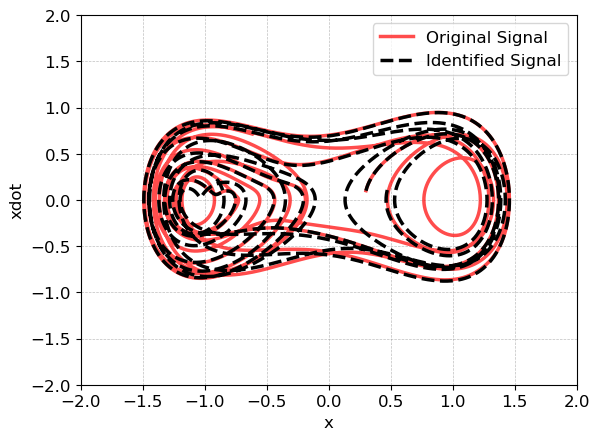

In [87]:
# velocity
plt.plot(x[:,0],x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(sim[:,0],sim[:,1],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("x")
plt.ylabel("xdot")
plt.xlim((-2,2))
plt.ylim((-2,2))
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('pp_duffing.pdf', format='pdf', dpi=300)
plt.show()

In [77]:
R2 = r2_score(x[:,0],sim[:,0])
MSE = mean_squared_error(x[:,0],sim[:,0])

print(f"R2 score: {R2}")
print(f"Mean Squared Error: {MSE}")

R2 score: 0.9998072776004471
Mean Squared Error: 1.8297695607792556e-06
